<a href="https://colab.research.google.com/github/MARIYA026/netflix-analysis/blob/main/netflix_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [100]:
import zipfile

# The zip file is located at /content/netflix_titles_nov_2019.csv.zip
zip_file_path = '/content/netflix_titles_nov_2019.csv.zip'
csv_file_name = 'netflix_titles_nov_2019.csv'

# Extract the CSV file from the zip archive
with zipfile.ZipFile(zip_file_path, 'r') as zf:
    zf.extract(csv_file_name, path='/content/')

# Load the extracted CSV into a pandas DataFrame
df = pd.read_csv(f'/content/{csv_file_name}')

# Display the first 5 rows of the DataFrame
display(df.head())

,show_id,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,type
0,81193313,Chocolate,NaN,"Ha Ji-won, Yoon Kye-sang, Jang Seung-jo, Kang ...",South Korea,"November 30, 2019",2019,TV-14,1 Season,"International TV Shows, Korean TV Shows, Roman...",Brought together by meaningful meals in the pa...,TV Show
1,81197050,Guatemala: Heart of the Mayan World,"Luis Ara, Ignacio Jaunsolo",Christian Morales,NaN,"November 30, 2019",2019,TV-G,67 min,"Documentaries, International Movies","From Sierra de las Minas to Esquipulas, explor...",Movie
2,81213894,The Zoya Factor,Abhishek Sharma,"Sonam Kapoor, Dulquer Salmaan, Sanjay Kapoor, ...",India,"November 30, 2019",2019,TV-14,135 min,"Comedies, Dramas, International Movies",A goofy copywriter unwittingly convinces the I...,Movie
3,81082007,Atlantics,Mati Diop,"Mama Sane, Amadou Mbow, Ibrahima Traore, Nicol...","France, Senegal, Belgium","November 29, 2019",2019,TV-14,106 min,"Dramas, Independent Movies, International Movies","Arranged to marry a rich man, young Ada is cru...",Movie
4,80213643,Chip and Potato,NaN,"Abigail Oliver, Andrea Libman, Briana Buckmast...","Canada, United Kingdom",NaN,2019,TV-Y,2 Seasons,Kids' TV,"Lovable pug Chip starts kindergarten, makes ne...",TV Show


In [101]:
print(df.shape)

(5837, 12)


In [102]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5837 entries, 0 to 5836
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       5837 non-null   int64 
 1   title         5837 non-null   object
 2   director      3936 non-null   object
 3   cast          5281 non-null   object
 4   country       5410 non-null   object
 5   date_added    5195 non-null   object
 6   release_year  5837 non-null   int64 
 7   rating        5827 non-null   object
 8   duration      5837 non-null   object
 9   listed_in     5837 non-null   object
 10  description   5837 non-null   object
 11  type          5837 non-null   object
dtypes: int64(2), object(10)
memory usage: 547.3+ KB


In [103]:
df.isnull().sum()


,0
show_id,0
title,0
director,1901
cast,556
country,427
date_added,642
release_year,0
rating,10
duration,0
listed_in,0


In [104]:
df['director'] =df['director'].fillna('unknown')
df['cast'] =df['cast'].fillna('unknown')
df['country'] =df['country'].fillna('unknown')
df['date_added'] =df['date_added'].fillna('unknown')
df['rating'] =df['rating'].fillna('unknown')

df.isnull().sum()



,0
show_id,0
title,0
director,0
cast,0
country,0
date_added,0
release_year,0
rating,0
duration,0
listed_in,0


In [105]:
df['type'].value_counts()

,count
type,
Movie,3939
TV Show,1898


In [106]:
df['country'].value_counts().head(10)

,count
country,
United States,1907
India,697
unknown,427
United Kingdom,336
Japan,168
Canada,139
South Korea,133
Spain,113
France,85


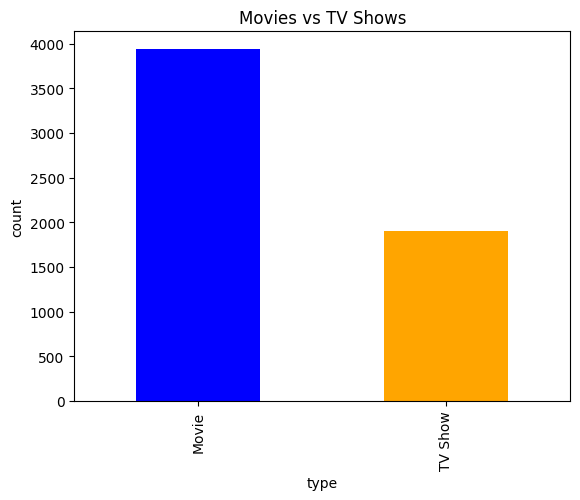

In [107]:
import matplotlib.pyplot as plt


df['type'].value_counts().plot(kind='bar', color=['blue','orange'])
plt.title('Movies vs TV Shows')
plt.ylabel('count')
plt.show()

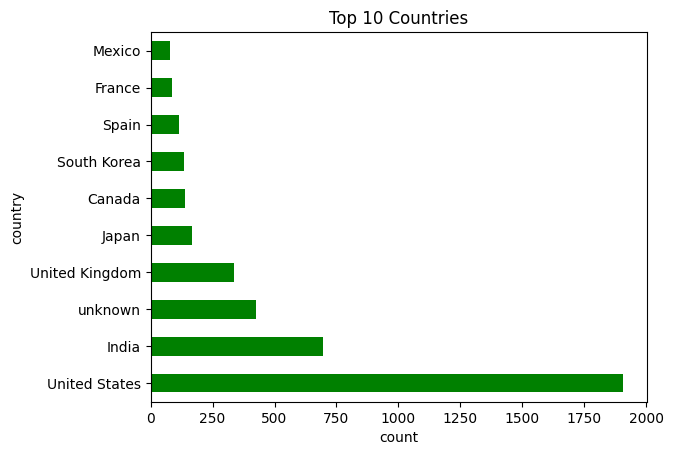

In [108]:
df['country'].value_counts().head(10).plot(kind='barh' , color='green')
plt.title('Top 10 Countries')
plt.xlabel('count')
plt.show()

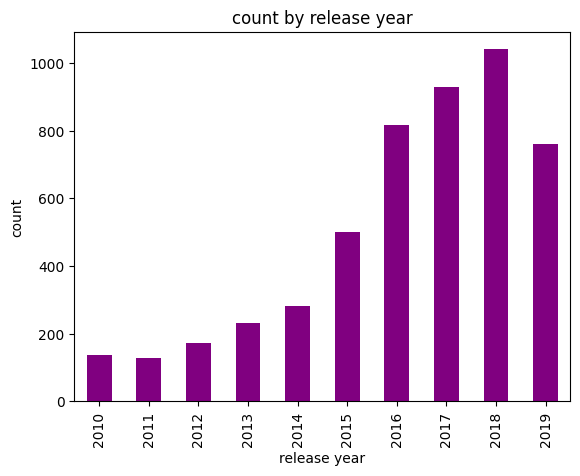

In [109]:
df['release_year'].value_counts().head(10).sort_index().plot(kind='bar', color='purple')
plt.title('count by release year')
plt.xlabel('release year')
plt.ylabel('count')
plt.show()

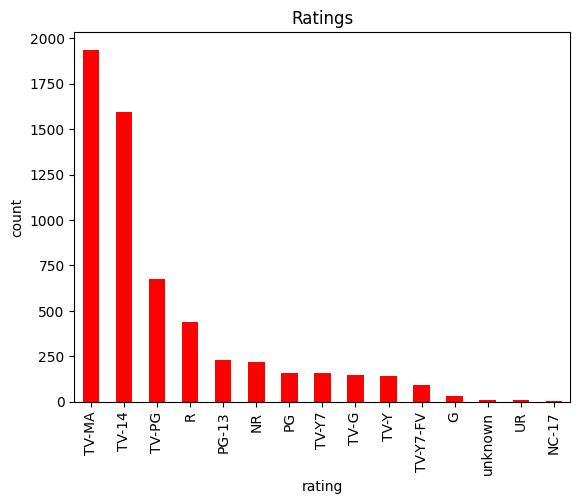

In [110]:
df['rating'].value_counts().plot(kind='bar', color='red')
plt.title('Ratings')
plt.xlabel('rating')
plt.ylabel('count')
plt.show()

In [111]:
df.tail()

,show_id,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,type
5832,70141644,Mad Ron's Prevues from Hell,Jim Monaco,"Nick Pawlow, Jordu Schell, Jay Kushwara, Micha...",United States,"November 1, 2010",1987,NR,84 min,"Cult Movies, Horror Movies","This collection cherry-picks trailers, forgott...",Movie
5833,70127998,Splatter,Joe Dante,"Corey Feldman, Tony Todd, Tara Leigh, Erin Way...",United States,"November 18, 2009",2009,TV-14,29 min,Horror Movies,"After committing suicide, a washed-up rocker r...",Movie
5834,70084180,Just Another Love Story,Ole Bornedal,"Anders W. Berthelsen, Rebecka Hemse, Nikolaj L...",Denmark,"May 5, 2009",2007,NR,104 min,"Dramas, International Movies",When he causes a car accident that leaves a yo...,Movie
5835,70157452,Dinner for Five,unknown,unknown,United States,"February 4, 2008",2007,TV-MA,1 Season,Stand-Up Comedy & Talk Shows,"In each episode, four celebrities join host Jo...",TV Show
5836,70053412,To and From New York,Sorin Dan Mihalcescu,"Barbara King, Shaana Diya, John Krisiukenas, Y...",United States,"January 1, 2008",2006,NR,81 min,"Dramas, Independent Movies, Thrillers","While covering a story in New York City, a Sea...",Movie
